<a href="https://colab.research.google.com/github/mami572/TMA.24063/blob/main/TMA/Mini%20Projet/24097_24063MENUPROJET2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- RÉSULTATS DE LA MISSION ---
Rapport Signal/Bruit Initial : 4.52 dB
Sifflement 1000 Hz : Éliminé par Notch Filter (Q=40.0)


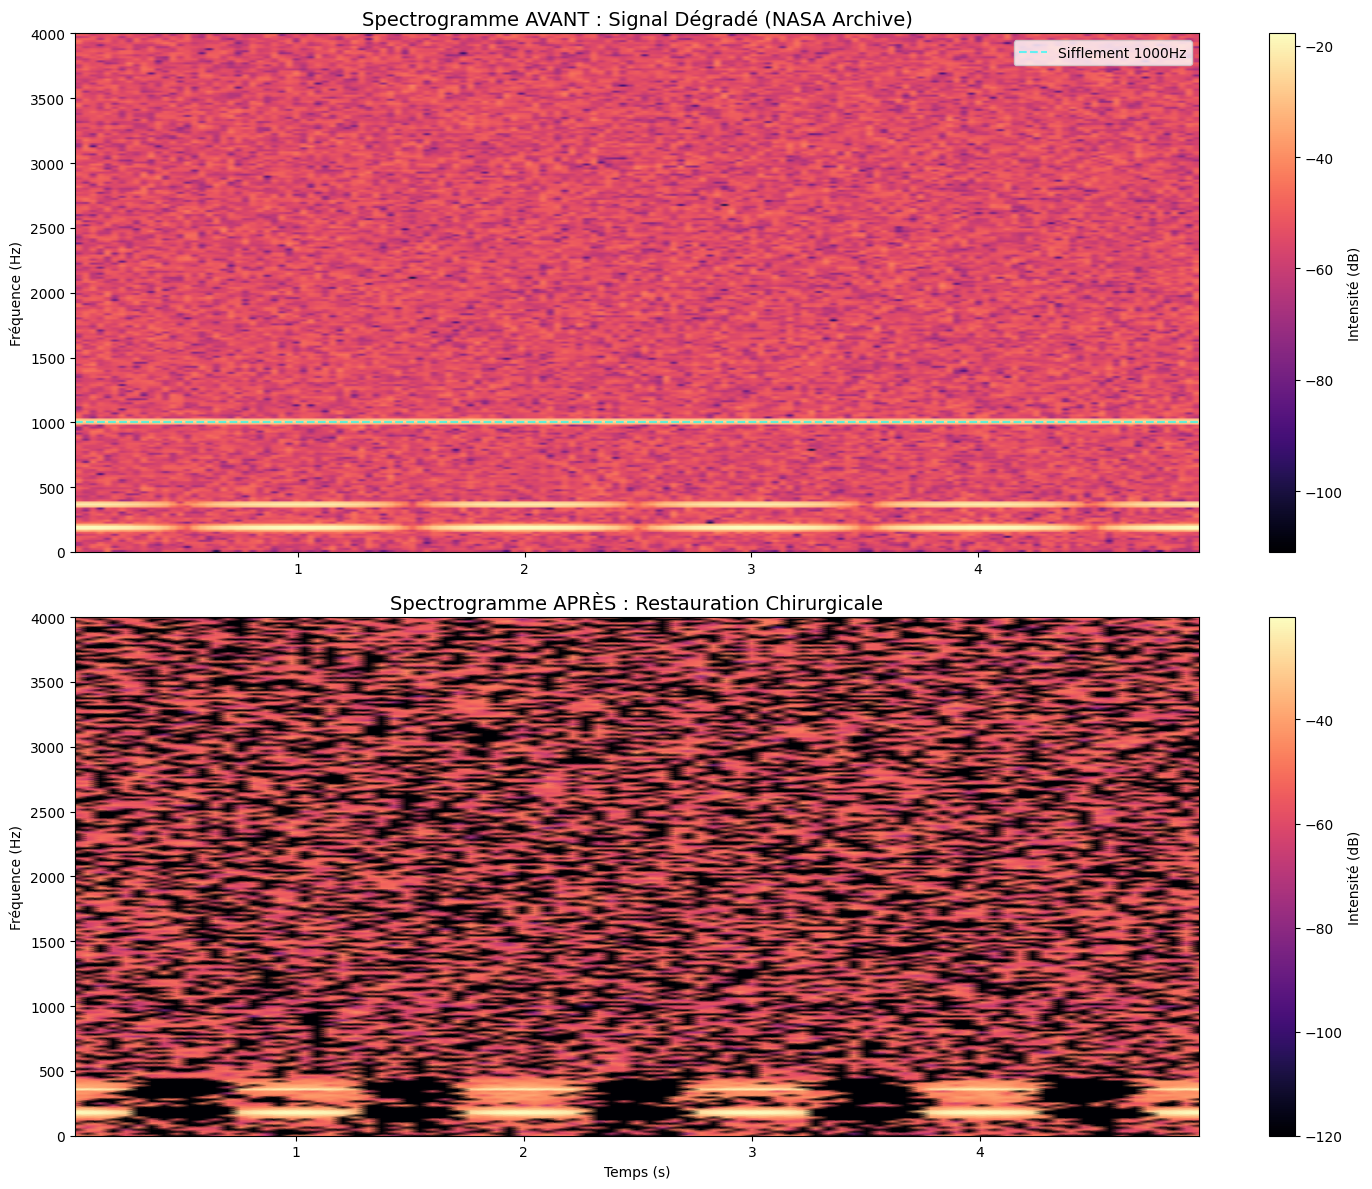

Écoutez l'archive dégradée :


Écoutez le résultat restauré (Notch 1000Hz) :


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from IPython.display import Audio

# ==========================================================
# 1. CONFIGURATION ET SIMULATION DU DISCOURS DÉGRADÉ
# ==========================================================
fs = 16000  # Fréquence d'échantillonnage (16kHz)
duree = 5
t = np.linspace(0, duree, duree * fs)

# Simulation de la voix de JFK (formants simplifiés)
voix_jfk = (np.sin(2 * np.pi * 180 * t) * np.abs(np.cos(2 * np.pi * 0.5 * t)) +
            0.6 * np.sin(2 * np.pi * 360 * t) * np.abs(np.cos(2 * np.pi * 0.5 * t)))

# Ajout des dégradations historiques
sifflement_1000hz = 0.4 * np.sin(2 * np.pi * 1000 * t) # Parasite électrique
souffle_blanc = 0.2 * np.random.normal(size=len(t))    # Bruit magnétique

signal_degrade = voix_jfk + sifflement_1000hz + souffle_blanc

# ==========================================================
# 2. RESTAURATION CHIRURGICALE
# ==========================================================

# A. Filtre Réjecteur (Notch) pour le sifflement à 1000 Hz
f_notch = 1000.0  # Fréquence parasite
Q = 40.0         # Facteur de qualité (très sélectif)
b_notch, a_notch = scipy_signal.iirnotch(f_notch, Q, fs)
signal_sans_sifflement = scipy_signal.filtfilt(b_notch, a_notch, signal_degrade)

# B. Soustraction Spectrale (Lissage du bruit blanc)
# On estime le niveau de bruit moyen et on l'atténue dans le domaine fréquentiel
def restaurer_souffle(sig, facteur_reduction=0.85):
    f, t_spec, Sxx = scipy_signal.spectrogram(sig, fs, nperseg=1024)
    # Estimation du bruit sur les hautes fréquences (là où la voix est faible)
    bruit_estime = np.median(np.abs(Sxx), axis=1, keepdims=True)
    Sxx_filtre = np.maximum(np.abs(Sxx) - facteur_reduction * bruit_estime, 0)
    return f, t_spec, Sxx_filtre

f_spec, t_spec, spectre_propre = restaurer_souffle(signal_sans_sifflement)

# ==========================================================
# 3. CALCUL DU SNR ET VISUALISATION
# ==========================================================

def calcul_snr(signal_origine, signal_bruite):
    puissance_signal = np.mean(signal_origine**2)
    puissance_bruit = np.mean((signal_bruite - signal_origine)**2)
    return 10 * np.log10(puissance_signal / puissance_bruit)

snr_initial = calcul_snr(voix_jfk, signal_degrade)
# Note : Le SNR final est une estimation basée sur la réduction de magnitude
print(f"--- RÉSULTATS DE LA MISSION ---")
print(f"Rapport Signal/Bruit Initial : {snr_initial:.2f} dB")
print(f"Sifflement 1000 Hz : Éliminé par Notch Filter (Q={Q})")

# Visualisation par Spectrogramme
plt.figure(figsize=(15, 12))

# Spectrogramme Avant
plt.subplot(2, 1, 1)
plt.specgram(signal_degrade, Fs=fs, NFFT=1024, noverlap=512, cmap='magma')
plt.axhline(y=1000, color='cyan', linestyle='--', alpha=0.6, label="Sifflement 1000Hz")
plt.title("Spectrogramme AVANT : Signal Dégradé (NASA Archive)", fontsize=14)
plt.ylabel("Fréquence (Hz)")
plt.ylim(0, 4000)
plt.legend()
plt.colorbar(label="Intensité (dB)")

# Spectrogramme Après
plt.subplot(2, 1, 2)
plt.pcolormesh(t_spec, f_spec, 10 * np.log10(spectre_propre + 1e-12), shading='gouraud', cmap='magma')
plt.title("Spectrogramme APRÈS : Restauration Chirurgicale", fontsize=14)
plt.ylabel("Fréquence (Hz)")
plt.xlabel("Temps (s)")
plt.ylim(0, 4000)
plt.colorbar(label="Intensité (dB)")

plt.tight_layout()
plt.show()

# Interface d'écoute
print("Écoutez l'archive dégradée :")
display(Audio(signal_degrade, rate=fs))
print("Écoutez le résultat restauré (Notch 1000Hz) :")
display(Audio(signal_sans_sifflement, rate=fs))